### update data source

In [1]:
import yfinance as yf
import pandas as pd
import datetime
import matplotlib.pyplot as plt
import seaborn as sns
from yfinance import EquityQuery
import logging

# Configure basic logging to console (default)
logging.basicConfig(level=logging.INFO) 
# logging.info("This is an info message.")
# logging.warning("This is a warning message.")


In [2]:
# import matplotlib.pyplot as plt

In [24]:
FMP_API_key = '2c2cd38706ef0b12bdbf80a33806aa32'
data_path = 'data_test'

### Economic Position

In [13]:
def MarketUpdate(save_his = False):

    market_tbl = pd.DataFrame(columns = ['closed_date', 'index', 'metric', 'val'])
    Market_US_summary = yf.Market('US').summary
    Market_US_status = yf.Market('US').status
    # market_tbl_new = pd.DataFrame(columns = market_tbl.columns.to_list()) #['nextopen_date','index','metric', 'val']
    # date = datetime.datetime.today().date().strftime("%Y-%m-%d")
    date = Market_US_status['open'][:10] #'2025-10-07' #Market_US_status['open'][:10]
    if date != datetime.date.today().strftime('%Y-%m-%d'):
        raise Exception('New market summary is not updated. Please reload the package or come back later.')
    else:
        if date in market_tbl.closed_date.to_list(): # to be updated
            market_tbl = market_tbl[market_tbl.closed_date != date]
            logging.info(f'''Data on {date} is refreshed''')
        for idx in Market_US_summary:
            for key, val in Market_US_summary[idx].items():
                if type(val) == float:
                    market_tbl.loc[len(market_tbl)] = [date, idx, key, val]
        logging.info(f'''Market index is retrived for {date}''')
        
        if save_his:
            market_tbl_his = pd.read_csv('market_tbl.csv')
            market_tbl_his = pd.concat([market_tbl_his, market_tbl])
            market_tbl.to_csv('market_tbl.csv', index = False)
            logging.info(f'''Updates are saved in historical table''')
        return date, market_tbl

In [14]:
closed_date, market_tbl = MarketUpdate()

ERROR:yfinance:US: Failed to update market status
ERROR:yfinance:US: Failed to update market status
INFO:root:Market index is retrived for 2025-10-27


In [15]:
market_tbl

,closed_date,index,metric,val
0,2025-10-27,CME,regularMarketChange,-2.699951
1,2025-10-27,CME,regularMarketChangePercent,-0.106633
2,2025-10-27,CME,regularMarketPrice,2529.300000
3,2025-10-27,CME,regularMarketPreviousClose,2532.000000
4,2025-10-27,CBT,regularMarketChange,16.000000
5,2025-10-27,CBT,regularMarketChangePercent,0.033535
6,2025-10-27,CBT,regularMarketPrice,47728.000000
7,2025-10-27,CBT,regularMarketPreviousClose,47712.000000
8,2025-10-27,CXI,regularMarketChange,-0.580001
9,2025-10-27,CXI,regularMarketChangePercent,-3.543072


In [16]:
closed_date

'2025-10-27'

In [56]:
table = 'industry_tbl'
file_path = os.path.join(data_path, table +'.csv')
exist = os.path.exists(file_path)

In [57]:
exist

True

In [55]:
file_path

'data_test/industry_tbl.csv.csv'

<!-- ### Sector Position -->

In [17]:
# sector_mapping = pd.read_csv('gics_to_yahoo_sector_mapping.csv').set_index('gics_sector')

In [18]:
# focus_section = ['Information Technology',
#  'Health Care',
#  'Financials',
#  'Consumer Discretionary',
#  'Consumer Staples',
#  'Communication Services'
# ]
# focus_gics_section = sector_mapping.loc[focus_section]

In [22]:
def SectorToIndustry(path, focus_section = ['Information Technology','Health Care','Financials','Consumer Discretionary',
                                      'Consumer Staples','Communication Services']
                    ):
    '''
    Get all sector names (gics standard) and their symbols (yahoo standard)
    input : pre-defined 6 sectors under gics standard
    output : industry table of the focus_section. columns: [industry_key, industry_name, industry_ticker, market_weight, sector] 
    - industry_key, industry_name, industry_ticker in yahoo standard
    - sector in yahoo standard
    '''

    sector_mapping = pd.read_csv(f'''{path}/gics_to_yahoo_sector_mapping.csv''').set_index('gics_sector')
    df_industry_sector = pd.DataFrame()
    focus_gics_section = sector_mapping.loc[focus_section]
    if len(focus_gics_section) != len(focus_section):
        raise Exception('One or more section cannot be found in the validated section list. Please review and update')
    else:
        focus_yahoo_section = focus_gics_section.yahoo_sector.to_list()
        for i in range(len(focus_yahoo_section)):
            sector_y = focus_yahoo_section[i]
            logging.info(f'''Get {sector_y} info under yahoo finance standard''')
            df_ = yf.Sector(sector_y).industries
            df_['sector'] = sector_y
            df_industry_sector = pd.concat([df_industry_sector, df_])
            # print(df_sector)
        df_industry_sector = df_industry_sector.reset_index()
        if 'key' not in df_industry_sector.columns or 'name' not in df_industry_sector.columns or 'symbol' not in df_industry_sector.columns:
            raise Exception('Please check the yahoo download table format')
        column_mapping = {
                            'key': 'industry_key',
                            'name': 'industry_name',
                            'symbol': 'industry_ticker',
                        }
        df_industry_sector.rename(columns=column_mapping, inplace=True)

            # df_sector = [df_sector.rename_axis(index = ['industry_key', 'industry_name', 'industry_ticker', 'market_weight', sector])
        return df_industry_sector#, focus_yahoo_section

In [25]:
df_industry_sector = SectorToIndustry(path = data_path) #focus_section, sector_mapping #, focus_yahoo_section
df_industry_sector

INFO:root:Get technology info under yahoo finance standard
INFO:root:Get healthcare info under yahoo finance standard
INFO:root:Get financial-services info under yahoo finance standard
INFO:root:Get consumer-cyclical info under yahoo finance standard
INFO:root:Get consumer-defensive info under yahoo finance standard
INFO:root:Get communication-services info under yahoo finance standard


,industry_key,industry_name,industry_ticker,market weight,sector
0,semiconductors,Semiconductors,^YH31130020,0.331033,technology
1,software-infrastructure,Software - Infrastructure,^YH31110030,0.264905,technology
2,consumer-electronics,Consumer Electronics,^YH31120030,0.162278,technology
3,software-application,Software - Application,^YH31110020,0.104552,technology
4,information-technology-services,Information Technology Services,^YH31110010,0.033468,technology
...,...,...,...,...,...
75,entertainment,Entertainment,^YH30820040,0.117995,communication-services
76,advertising-agencies,Advertising Agencies,^YH30820010,0.036731,communication-services
77,electronic-gaming-multimedia,Electronic Gaming & Multimedia,^YH30830020,0.024122,communication-services
78,broadcasting,Broadcasting,^YH30820030,0.001752,communication-services


In [26]:
# section_tbl = pd.read_csv('f0_industry_of_interested_sectors.csv')

In [27]:
# section_tbl

In [28]:
closed_date

'2025-10-27'

In [29]:
def IndustryPositionFact(date, df_industry_sector, save_his = False):
    
    industry_tbl = pd.DataFrame(columns = ['closed_date', 'sector', 'industry_key', 'industry_name', 'industry_ticker', 'metric', 'val'])

    for i in range(len(df_industry_sector.industry_ticker)):
        industry_key = df_industry_sector.industry_key.iloc[i]
        industry_name = df_industry_sector.industry_name.iloc[i]
        industry_ticker = df_industry_sector.industry_ticker.iloc[i]
        sector = df_industry_sector.sector.iloc[i]
        # print(industry)
        df_ = yf.Ticker(industry_ticker).info
        for key, val in df_.items():
            if type(val) == float:
                industry_tbl.loc[len(industry_tbl)] = [date, sector, industry_key, industry_name, industry_ticker, key, val]
    logging.info(f'''Industry postion is retrieved for {date}''')

    if save_his:
        industry_tbl_his = pd.read_csv('industry_tbl.csv')
        if date in industry_tbl_his.closed_date.to_list(): #not in section_tbl.nextopen_date.to_list(): # to be updated
            industry_tbl_his = industry_tbl_his[industry_tbl_his.closed_date != date]
            logging.info(f'''Data on {date} is refreshed''')
        industry_tbl_his = pd.concat([industry_tbl_his, industry_tbl])
        industry_tbl_his.to_csv('industry_tbl.csv', index = False)
        logging.info(f'''Industry metrics on {date} is saved in industry_tbl''')
    
    return industry_tbl

In [30]:
industry_tbl = IndustryPositionFact(closed_date, df_industry_sector)
industry_tbl

INFO:root:Industry postion is retrieved for 2025-10-27


,closed_date,sector,industry_key,industry_name,industry_ticker,metric,val
0,2025-10-27,technology,semiconductors,Semiconductors,^YH31130020,previousClose,4.724150e+06
1,2025-10-27,technology,semiconductors,Semiconductors,^YH31130020,regularMarketPreviousClose,4.724150e+06
2,2025-10-27,technology,semiconductors,Semiconductors,^YH31130020,fiftyTwoWeekLow,3.884657e+06
3,2025-10-27,technology,semiconductors,Semiconductors,^YH31130020,fiftyTwoWeekHigh,7.986656e+06
4,2025-10-27,technology,semiconductors,Semiconductors,^YH31130020,fiftyDayAverage,7.420063e+06
...,...,...,...,...,...,...,...
1515,2025-10-27,communication-services,publishing,Publishing,^YH30820020,fiftyTwoWeekLowChange,2.134496e+03
1516,2025-10-27,communication-services,publishing,Publishing,^YH30820020,fiftyTwoWeekLowChangePercent,2.033496e-01
1517,2025-10-27,communication-services,publishing,Publishing,^YH30820020,fiftyTwoWeekHighChange,-1.249011e+03
1518,2025-10-27,communication-services,publishing,Publishing,^YH30820020,fiftyTwoWeekHighChangePercent,-8.998515e-02


In [31]:
def IndustryFilter_Trend(date, industry_tbl):
    df = industry_tbl[industry_tbl.closed_date == date]
    analysis_industry_tbl_new = df.pivot(index=['closed_date', 'industry_key', 'industry_ticker'], 
                                                columns='metric', values='val').reset_index()
    industry_list_50days = analysis_industry_tbl_new[analysis_industry_tbl_new.previousClose > 
                          analysis_industry_tbl_new.fiftyDayAverage * (1+abs(analysis_industry_tbl_new.fiftyDayAverageChangePercent))]
    industry_list_200days = analysis_industry_tbl_new[analysis_industry_tbl_new.previousClose > 
                              analysis_industry_tbl_new.twoHundredDayAverage * (1+abs(analysis_industry_tbl_new.twoHundredDayAverageChangePercent))]
    
    industry_list_set = set(industry_list_50days.industry_key) & set(industry_list_200days.industry_key)

        
    return industry_list_set

In [32]:
# industry_filtered = IndustryFilter_Trend(closed_date, industry_tbl)
# industry_filtered

In [33]:
def IndustryPrioritization(date, df_industry_sector, industry_tbl, filterfunction = IndustryFilter_Trend, save_his = False):
    industry_prioritize = df_industry_sector[['industry_key', 'industry_name', 'industry_ticker', 'sector']]
    industry_prioritize['closed_date'] = date
    industry_prioritize['Prioritize'] = False
    industry_list_set = filterfunction(date = date, industry_tbl = industry_tbl)
    industry_prioritize.loc[industry_prioritize['industry_key'].isin(industry_list_set),'Prioritize'] = True
    industry_prioritize = industry_prioritize.sort_values(by = 'Prioritize', ascending = False)
    
    if save_his:
        industry_prioritize_his = pd.read_csv('industry_prioritize.csv')
    
        if industry_prioritize.columns != industry_prioritize_his.columns:
            raise Exception('industry_prioritize table format does not match expactation')
        else:
            industry_prioritize_his = pd.concat([industry_prioritize_his, industry_prioritize])
            industry_prioritize_his.to_csv('industry_prioritize.csv', index = False)
            print(f'''industry_prioritize on {date} is saved in histroical table''')
    return industry_prioritize

In [34]:
industry_prioritize = IndustryPrioritization(date = closed_date, df_industry_sector = df_industry_sector, industry_tbl = industry_tbl)
industry_prioritize

,industry_key,industry_name,industry_ticker,sector,closed_date,Prioritize
49,footwear-accessories,Footwear & Accessories,^YH10240030,consumer-cyclical,2025-10-27,True
35,insurance-reinsurance,Insurance - Reinsurance,^YH10340030,financial-services,2025-10-27,True
16,healthcare-plans,Healthcare Plans,^YH20630010,healthcare,2025-10-27,True
66,confectioners,Confectioners,^YH20525010,consumer-defensive,2025-10-27,True
10,solar,Solar,^YH31130030,technology,2025-10-27,True
...,...,...,...,...,...,...
26,capital-markets,Capital Markets,^YH10330010,financial-services,2025-10-27,False
25,asset-management,Asset Management,^YH10310010,financial-services,2025-10-27,False
24,credit-services,Credit Services,^YH10360010,financial-services,2025-10-27,False
23,banks-diversified,Banks - Diversified,^YH10320010,financial-services,2025-10-27,False


In [21]:
# f1_industry = analysis_section_tbl_new[analysis_section_tbl_new.previousClose > 
#                           analysis_section_tbl_new.twoHundredDayAverage * (1+abs(analysis_section_tbl_new.twoHundredDayAverageChangePercent))]
# f1_industry.loc[:,'gap_above'] = f1_industry.previousClose - f1_industry.twoHundredDayAverage * (1+abs(f1_industry.twoHundredDayAverageChangePercent))
# f1_industry = f1_industry.sort_values(by='gap_above', ascending=False)
# f1_industry.to_csv('20251008_f1_induftry.csv')

### Ticker info

In [22]:
from collections import Counter

In [23]:
def TrendWindow(df, col, window_size):
    '''
    how many days does each uptrend window last
    '''
    # i = window_size
    uptrend, his = [], []
    length, i = 0, 0
    while i < len(df):
        # print(his)
        if i < window_size:
            his.append(df[col].iloc[i])
        else:
            avg = sum(his)/window_size
            his.pop(0)
            current = df[col].iloc[i]
            if  current > avg:
                length += 1
            else:
                if length != 0:
                    uptrend.append(length)
                    length = 0

            his.append(current)
        i += 1
    uptrend.sort()
    return uptrend
        

In [24]:
def customized_bin():
    fib = [1,1]
    end = 1000
    fib_binname = []
    i = 2
    while i < 13:
        nxt = fib[i-1] + fib[i-2]
        fib.append(nxt)
        i += 1
        # print(fib)
        binname = f'''bin{fib[i-2]}_{fib[i-1]}'''
        # print(binname)
        fib_binname.append(binname)
    fib_binname.append(f'''bin{fib[-1]}_{end}''')
    fib.append(end)
    # fib[0] = 0
    fib.pop(0)
    return fib, fib_binname

In [25]:
import numpy as np

In [26]:
# industry_tbl, closed_date

In [27]:
# # Row-wise percentages (per row total)
# def row_bin_counts(values):
#     arr = np.array(values, dtype=float)
#     if arr.size == 0:
#         return np.zeros(len(bins_labels), dtype=int)
#     counts, _ = np.histogram(arr, bins=bins)
#     return counts
    
# counts_df = ['trend_counter'].apply(row_bin_counts).apply(pd.Series)
# counts_df.columns = bins_labels

# row_totals = counts_df.sum(axis=1).replace(0, np.nan)  # avoid div-by-zero
# pct_df = counts_df.div(row_totals, axis=0).fillna(0.0) * 100.0
# pct_df = pct_df.round(2)
# bins_labels_pct = [f"{b}_pct" for b in bins_labels]
# pct_df.columns = bins_labels_pct

# # Final table: id columns + counts + percentages
# # df_trend_binned = pd.concat([df_industry_trend_binned[['industry', 'industry_code']].reset_index(drop=True),
# #                              counts_df.reset_index(drop=True),
# #                              pct_df.reset_index(drop=True)],
# #                             axis=1)
# df_trend_binned_pct = pd.concat([df_industry_trend_binned[['industry', 'industry_code']].reset_index(drop=True),
#                              pct_df.reset_index(drop=True).round()],
#                             axis=1)

### Stocks

In [28]:
industry_list = industry_prioritize.industry_key.to_list()

In [29]:
industry_list

['Beverages - Wineries & Distilleries',
 'Confectioners',
 'Department Stores',
 'Drug Manufacturers - General',
 'Footwear & Accessories',
 'Healthcare Plans',
 'Insurance - Reinsurance',
 'Packaging & Containers',
 'Recreational Vehicles',
 'Residential Construction',
 'Shell Companies',
 'Solar',
 'Specialty Retail']

In [31]:
# how long does a stock stay above the 52 weeks high 

In [32]:
# Price > 50-DMA and 200-DMA

# RSI between 45–65 (pullback zone)
#### RSI = 100 - 100/1+RS (RS = Avg Gain / AVG Loss)


# Volume > 1.5× 20-day average

# MACD bullish crossover (above 0 line)

# Optional catalyst: recent earnings beat / analyst upgrade and the target is > 10% higher than current price



In [33]:
# Price > 50-DMA

# 50-DMA > 200-DMA (uptrend)

# RSI rebounds from 40–50 range

# MACD bullish crossover

# Volume > 1.5× 20-day average

# Relative Strength line rising vs. index

# Earnings/revenue growth positive (fundamental momentum)

# Analyst upgrades or target hikes

# S&P 500/Nasdaq in uptrend (macro tailwind)

# ATR-based stop defined (risk control)

In [165]:
def price_above_dma(data, window_size=50):
    """
    Checks if the most recent closing price is above its moving average (DMA).
    
    Parameters:
        data (pd.DataFrame): Historical price data with a 'Close' column.
        window_size (int): Moving average period (default 50).
    
    Returns:
        bool: True if latest price > DMA, else False.
    """

    # --- 1. Validate input ---
    if "Close" not in data.columns:
        raise ValueError("Input DataFrame must contain a 'Close' column.")

    if len(data) < window_size:
        raise ValueError(f"Not enough data to compute {window_size}-day moving average.")

    # --- 2. Compute DMA ---
    data = data.copy()
    data[f"{window_size}_DMA"] = data["Close"].rolling(window=window_size).mean()

    # --- 3. Check last price vs. DMA ---
    latest_close = data["Close"].iloc[-1]
    latest_dma = data[f"{window_size}_DMA"].iloc[-1]

    return bool(latest_close > latest_dma)

In [166]:
def dma_crossover_test(data, window_size_short=50, window_size_long=200):
    """
    Tests if the short-term DMA (e.g., 50-DMA) is above the long-term DMA (e.g., 200-DMA).
    Returns True if bullish crossover (Golden Cross), else False.
    
    Parameters:
        data (pd.DataFrame): Historical price data with a 'Close' column.
        window_size_short (int): Short-term moving average window (default 50).
        window_size_long (int): Long-term moving average window (default 200).
    
    Returns:
        bool: True if latest short DMA > latest long DMA, else False.
    """

    # --- 1. Validate input ---
    if "Close" not in data.columns:
        raise ValueError("Input DataFrame must contain a 'Close' column.")
    
    if len(data) < window_size_long:
        raise ValueError(f"Not enough data to compute {window_size_long}-day moving average.")

    # --- 2. Compute both moving averages ---
    data = data.copy()
    data[f"{window_size_short}_DMA"] = data["Close"].rolling(window=window_size_short).mean()
    data[f"{window_size_long}_DMA"] = data["Close"].rolling(window=window_size_long).mean()

    # --- 3. Compare latest values ---
    short_dma = data[f"{window_size_short}_DMA"].iloc[-1]
    long_dma = data[f"{window_size_long}_DMA"].iloc[-1]

    return bool(short_dma > long_dma)

In [167]:
def macd_bullish_test(data, EMA_short=12, EMA_long=26, EMA_signal=9, lookback_days=3):
    """
    Checks whether a stock recently passed the MACD bullish crossover test.
    
    Parameters:
        data (pd.DataFrame, optional): Historical price data with a 'Close' column.
                                       If None, data will be downloaded automatically.
        EMA_short (int): Short-term EMA period (default 12)
        EMA_long (int): Long-term EMA period (default 26)
        EMA_signal (int): Signal EMA period (default 9)
        lookback_days (int): Days to check for recent crossover (default 3)
    
    Returns:
        bool: True if recent bullish MACD crossover detected, else False
    """

    # --- 1. Load data if not provided ---
    if data is None:
        raise ValueError("Input data does not exist")


    # Ensure required column exists
    if "Close" not in data.columns:
        raise ValueError("Input data must contain a 'Close' column.")

    # --- 2. Compute EMAs ---
    data["EMA_short"] = data["Close"].ewm(span=EMA_short, adjust=False).mean()
    data["EMA_long"] = data["Close"].ewm(span=EMA_long, adjust=False).mean()

    # --- 3. Compute MACD and Signal Line ---
    data["MACD"] = data["EMA_short"] - data["EMA_long"]
    data["Signal"] = data["MACD"].ewm(span=EMA_signal, adjust=False).mean()

    # --- 4. Check for recent bullish crossover ---
    data["Crossover"] = (data["MACD"] > data["Signal"]) & (data["MACD"].shift(1) <= data["Signal"].shift(1))

    recent_crossover = data.tail(lookback_days)["Crossover"].any()

    # --- 5. Confirm MACD > 0 (optional filter for momentum strength) ---
    if recent_crossover and data["MACD"].iloc[-1] > 0:
        return True
    else:
        return False

In [168]:
def volume_surge_test(data, window_size=20, multiplier=1.5):
    """
    Tests if the latest daily trading volume is greater than (multiplier × N-day average volume).

    Parameters:
        data (pd.DataFrame): Historical price data with a 'Volume' column.
        window_size (int): Number of days for average volume (default 20).
        multiplier (float): Threshold multiplier (default 1.5 → 50% above average).

    Returns:
        bool: True if latest volume > multiplier × average volume, else False.
    """

    # --- 1. Validate input ---
    if "Volume" not in data.columns:
        raise ValueError("Input DataFrame must contain a 'Volume' column.")
    if len(data) < window_size:
        raise ValueError(f"Not enough data to compute {window_size}-day average volume.")

    # --- 2. Compute rolling average volume ---
    data = data.copy()
    data[f"{window_size}_day_avg_volume"] = data["Volume"].rolling(window=window_size).mean()

    # --- 3. Compare latest volume to average ---
    latest_vol = data["Volume"].iloc[-1]
    avg_vol = data[f"{window_size}_day_avg_volume"].iloc[-1]

    return bool(latest_vol > multiplier * avg_vol)


In [169]:
import pandas as pd
import numpy as np
import yfinance as yf

def index_trend_test(data, symbol="^GSPC", window_size=20, ma_window=55, slope_threshold=0):
    """
    Tests whether a market index (e.g., S&P 500) is in an up or flat trend.
    Returns True if trend is up or flat, else False (downtrend).

    Parameters:
        data (pd.DataFrame, optional): Historical price data with a 'Close' column.
                                       If None, data will be fetched automatically for the symbol.
        symbol (str): Index ticker (default '^GSPC' = S&P 500).
        window_size (int): Lookback period to calculate trend slope (default 20 days).
        ma_window (int): Moving average window to confirm trend alignment (default 50 days).
        slope_threshold (float): Minimum acceptable slope (default 0 → flat or uptrend passes).

    Returns:
        bool: True if trend is up or flat, else False.
    """

    # --- 1. Fetch data if not provided ---
    index_data = yf.download(symbol, period="3y", interval="1d", progress=False, auto_adjust = False)

    if "Close" not in data.columns:
        raise ValueError("Input DataFrame must contain a 'Close' column.")
        
    if "Close" not in index_data.columns:
        raise ValueError("Index DataFrame must contain a 'Close' column.")
        
    if len(data) < max(window_size, ma_window):
        raise ValueError("Not enough data to compute trend metrics.")

    # --- 2. Compute slope of recent trend ---
    y = index_data["Close"].tail(window_size)
    x = np.arange(len(y))
    slope = np.polyfit(x, y, 1)[0]  # slope of linear regression line

    # --- 3. Compute moving average alignment ---
    index_data[f"{ma_window}_DMA"] = index_data["Close"].rolling(window=ma_window).mean()
    price_above_ma = index_data["Close"].iloc[-1] >= index_data[f"{ma_window}_DMA"].iloc[-1]

    # --- 4. Determine trend status ---
    trend_up_or_flat = (slope >= slope_threshold) and price_above_ma

    return bool(trend_up_or_flat)


In [170]:
import pandas as pd

def remove_non_trading_days(df: pd.DataFrame) -> pd.DataFrame:
    """
    Remove weekends, holidays, and non-trading rows from yfinance data.
    
    Logic:
      - Drop rows with all NaNs in OHLC
      - Drop rows with 0 volume (if column exists)
      - Drop duplicate calendar rows (if weekends appear)
      - Return DataFrame indexed only by actual market trading days.
    
    Parameters
    ----------
    df : pd.DataFrame
        The DataFrame returned by yfinance.download()

    Returns
    -------
    pd.DataFrame
        Cleaned DataFrame containing only trading sessions.
    """

    if df.empty:
        return df

    df_clean = df.copy()

    # Drop rows with all NaN prices
    ohlc_cols = [c for c in ["Open", "High", "Low", "Close"] if c in df_clean.columns]
    df_clean = df_clean.dropna(subset=ohlc_cols, how="all")

    # Drop rows with 0 volume (if Volume column exists)
    if "Volume" in df_clean.columns:
        df_clean = df_clean[df_clean["Volume"] != 0]

    # Ensure index is datetime and sorted
    if not isinstance(df_clean.index, pd.DatetimeIndex):
        df_clean.index = pd.to_datetime(df_clean.index, errors="coerce")
    df_clean = df_clean.sort_index().dropna(subset=ohlc_cols, how="all")

    # Drop duplicates (can occur if weekend filler exists)
    df_clean = df_clean[~df_clean.index.duplicated(keep="first")]

    return df_clean


In [202]:
def GetTicker_MarketCapital(
        # industry filter params
    date: str,
    industry_candidate: pd.DataFrame,
    indsutry_filter_func = None,
    lower_mp = 10000000000,
    higher_mp = 50000000000,
    save_his = False
    ):

    stock_tbl = pd.DataFrame(columns = ['closed_date', 'industry_name', 'stock_ticker', 'stock_name', "epsTrailingTwelveMonths","epsCurrentYear","epsForward","priceEpsCurrentYear"])
    fields = ["symbol","longName","epsTrailingTwelveMonths","epsCurrentYear","epsForward","priceEpsCurrentYear"]
    rename_mapping = {'symbol' : 'stock_ticker', 'longName' : 'stock_name'}
    
    for i in range(len(industry_candidate)):
        industry_name = industry_candidate['industry_name'].iloc[i]
        offset = 0
        logging.info(f'''appending stock info of {industry_name}''')
        rows = []

        try:
            q = EquityQuery('and', [
                    EquityQuery('EQ', ['region', 'us']),
                    EquityQuery('EQ', ['industry', industry_name]),
                    EquityQuery('GTE', ['intradaymarketcap', lower_mp]),
                    EquityQuery('LT', ['intradaymarketcap', higher_mp]),
                    EquityQuery('IS-IN', ['exchange', 'NMS', 'NYQ'])
                    ])

            while True:
                r = yf.screen(q, size=250, offset=offset, sortField='intradaymarketcap', sortAsc=False)
                quotes = r.get('quotes', [])
                if not quotes:
                    break
                for q in quotes:
                    row = {f: q.get(f, None) for f in fields}
                    # print(row)
                    if row:
                        rows.append(row)
                if len(quotes) < 250:
                    break
                offset += 250
            logging.info(f'''{len(rows)} tickers saved.''')
            if rows:
                df_quotes = pd.DataFrame(rows)
                df_quotes = df_quotes.rename(columns=rename_mapping)
                df_quotes['closed_date'] = date
                df_quotes['industry_name'] = industry_name    
                stock_tbl = pd.concat([stock_tbl, df_quotes], ignore_index = True)
 
        except:
            logging.info(f'''WARNING : {industry_name} is not a validate name in the pool''')
    if save_his:
        stock_tbl_his = pd.read_csv('stock_tbl.csv')
        
        if stock_tbl_his.columns != stock_tbl.columns:
            raise Exception ('stock_tbl format does not match with expectation')
            
        stock_tbl_his = pd.concat([stock_tbl_his, stock_tbl])
        stock_tbl_his.to_csv('stock_tbl.csv')
    return stock_tbl

In [203]:
stock_tbl = GetTicker_MarketCapital(date = closed_date, industry_candidate = industry_prioritize)

INFO:root:appending stock info of Footwear & Accessories
INFO:root:2 tickers saved.
/var/folders/tp/v0n0qm856pj6hmn6dd81rbgw0000gn/T/ipykernel_61430/519218954.py:49: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  stock_tbl = pd.concat([stock_tbl, df_quotes], ignore_index = True)
INFO:root:appending stock info of Insurance - Reinsurance
INFO:root:WARNING : Insurance - Reinsurance is not a validate name in the pool
INFO:root:appending stock info of Healthcare Plans
INFO:root:2 tickers saved.
INFO:root:appending stock info of Confectioners
INFO:root:1 tickers saved.
INFO:root:appending stock info of Department Stores
INFO:root:0 tickers saved.
INFO:root:appending stock info of Solar
INFO:root:2 tickers saved.
INFO:root:appending stock info of B

In [204]:
stock_tbl

,date,industry_name,stock_ticker,stock_name,epsTrailingTwelveMonths,epsCurrentYear,epsForward,priceEpsCurrentYear
0,2025-10-23,Footwear & Accessories,ONON,On Holding AG,0.53,0.61164,1.10,68.111960
1,2025-10-23,Footwear & Accessories,DECK,Deckers Outdoor Corporation,6.73,6.39867,6.36,13.807556
2,2025-10-23,Healthcare Plans,HUM,Humana Inc.,13.05,17.03984,16.84,16.930616
3,2025-10-23,Healthcare Plans,CNC,Centene Corporation,4.12,1.67240,7.04,20.476560
4,2025-10-23,Confectioners,HSY,The Hershey Company,7.54,5.95661,8.40,30.199188
...,...,...,...,...,...,...,...,...
237,2025-10-23,Asset Management,IVZ,Invesco Ltd.,0.93,1.80971,1.89,12.689878
238,2025-10-23,Asset Management,SEIC,SEI Investments Company,5.43,4.99333,4.88,16.465965
239,2025-10-23,Credit Services,SOFI,"SoFi Technologies, Inc.",0.50,0.31970,0.29,91.476390
240,2025-10-23,Credit Services,SYF,Synchrony Financial,9.12,9.29522,6.47,8.070923


In [44]:
df_date_data_tracker = pd.read_csv(f'''{data_path}/df_date_data_tracker.csv''')
if '2025-10-27' in df_date_data_tracker.closed_date.to_list():
    print('y')

y


In [ ]:
df_date_data_tracker = pd.read_csv(f'''{data_path}/df_date_data_tracker.csv''')
print('aaaaa', date)
if date in df_date_data_tracker.closed_date.to_list():

In [75]:
stock_metrics_full = pd.read_csv(f"{data_path}/stock_metrics.csv")

In [76]:
date = '2025-10-27'
stock_metrics_for_date = (
        stock_metrics_full[stock_metrics_full.closed_date == date]
        .reset_index(drop=True)
    )

In [77]:
len(stock_metrics_full)

2944

In [78]:
stock_metrics_full

,closed_date,industry_name,stock_ticker,stock_name,metric,metric_test
0,2025-10-27,Healthcare Plans,HUM,Humana Inc.,macd_bullish,False
1,2025-10-27,Healthcare Plans,HUM,Humana Inc.,price_above_8dma,True
2,2025-10-27,Healthcare Plans,HUM,Humana Inc.,dma_3_gt_21,True
3,2025-10-27,Healthcare Plans,HUM,Humana Inc.,volume_surge,False
4,2025-10-27,Healthcare Plans,CNC,Centene Corporation,macd_bullish,False
...,...,...,...,...,...,...
2939,2025-10-29,Credit Services,SYF,Synchrony Financial,volume_surge,False
2940,2025-10-29,Credit Services,ALLY,Ally Financial Inc.,macd_bullish,False
2941,2025-10-29,Credit Services,ALLY,Ally Financial Inc.,price_above_8dma,False
2942,2025-10-29,Credit Services,ALLY,Ally Financial Inc.,dma_3_gt_21,True


In [71]:
stock_metrics_for_date

,closed_date,industry_name,stock_ticker,stock_name,metric,metric_test


In [6]:
import pandas as pd

def flatten_yf_data(df: pd.DataFrame, keep_first: bool = True, ticker: str = None) -> pd.DataFrame:
    """
    Flatten yfinance multi-index DataFrame (Price, Ticker) into single-level columns.
    If multi-indexed, keeps only the first ticker or a specified one.

    Parameters
    ----------
    df : pd.DataFrame
        DataFrame returned by yfinance.download() which may have MultiIndex columns.
    keep_first : bool, default True
        If True, keep only the first ticker in the MultiIndex.
    ticker : str, optional
        Specify a ticker symbol to extract instead of the first one.

    Returns
    -------
    pd.DataFrame
        Single-index DataFrame (columns = 'Open', 'High', 'Low', 'Close', 'Volume', ...).
    """

    if df.empty:
        return df

    # --- Check if columns are multi-indexed ---
    if isinstance(df.columns, pd.MultiIndex):
        # Level names often look like ['Price', 'Ticker'] or [None, None]
        price_level, ticker_level = df.columns.names

        # Get available tickers (level 1)
        tickers_available = df.columns.get_level_values(1).unique().tolist()

        # Choose which ticker to keep
        if ticker is not None and ticker in tickers_available:
            target_ticker = ticker
        elif keep_first:
            target_ticker = tickers_available[0]
        else:
            raise ValueError(
                f"Multiple tickers found: {tickers_available}. Please specify one using `ticker=`."
            )

        # --- Filter only columns for the chosen ticker ---
        df = df.xs(target_ticker, axis=1, level=1)

        # Drop the remaining top-level (now single-level columns)
        df.columns.name = None
        df = df.copy()

    else:
        # Not multi-indexed — nothing to flatten
        df = df.copy()

    return df


In [234]:
import yfinance as yf
import pandas as pd
from yfinance import EquityQuery

# --- Assumes the following helper functions are already defined in your codebase ---
# macd_bullish_test(stock_code, data=None, EMA_short=12, EMA_long=26, EMA_signal=9, lookback_days=3) -> bool
# price_above_dma(data, window_size=50) -> bool
# dma_crossover_test(data, window_size_short=50, window_size_long=200) -> bool
# volume_surge_test(data, window_size=20, multiplier=1.5) -> bool
# index_trend_test(data=None, symbol="^GSPC", window_size=20, ma_window=50, slope_threshold=0.0) -> bool
# -------------------------------------------------------------------------------

def StockMetrics(
    date: str,
    stock_tbl: pd.DataFrame, # = stock_list,
    # *,
    # Stock filter params
    # yfinance fetch params
    period: str = "3y",
    interval: str = "1d",
    # MACD params
    ema_short: int = 13, #12,
    ema_long: int = 21, #26,
    ema_signal: int = 8, #9,
    macd_lookback_days: int = 3,
    # Price > DMA params
    dma_window: int = 8, #50,
    # 50/200 trend params
    dma_short: int = 3, #50,
    dma_long: int = 21, #200,
    # Volume surge params
    volume_window: int = 3,
    volume_multiplier: float = 1.3, #1.5,
    # Index trend params
    index_symbol: str = "^GSPC",
    index_window: int = 20,
    index_ma_window: int = 50,
    index_slope_threshold: float = 0.0,
    save_his = False,
) -> pd.DataFrame:
    """
    Iterate an industry->(code, [tickers]) pool, fetch data, run tests, and return a boolean results table.

    Parameters
    ----------
    industry_stocks : dict
        Shape: {industry_name: [industry_code, [tickers]]}
    period, interval : str
        yfinance download parameters for each stock (default 6mo, 1d).
    ema_short, ema_long, ema_signal, macd_lookback_days : int
        MACD settings and lookback window for recent crossover detection.
    dma_window : int
        Window for Price > DMA test (default 50).
    dma_short, dma_long : int
        Windows for short/long DMA crossover test (default 50/200).
    volume_window, volume_multiplier : int, float
        Rolling window and multiplier for volume surge test (default 20, 1.5x).
    index_symbol, index_window, index_ma_window, index_slope_threshold : ...
        Settings for the market trend filter (S&P 500 up/flat by default).

    Returns
    -------
    pd.DataFrame
        Columns: industry_name, industry_code, stock_code,
                 macd_bullish, price_above_{dma_window}dma,
                 dma_{dma_short}_gt_{dma_long}, volume_surge,
                 market_trend_up_or_flat, all_pass
    """

    rows = []
    
    for i in range(len(stock_tbl)):
        stock_ticker = stock_tbl['stock_ticker'].iloc[i]
        stock_name = stock_tbl['stock_name'].iloc[i]
        industry_name = stock_tbl['industry_name'].iloc[i]

        df = flatten_yf_data(yf.download(stock_ticker, period=period, interval=interval, progress=False, auto_adjust=False))
        df = remove_non_trading_days(df)

        # Guard: ensure data has Close & Volume and enough rows
        has_close = "Close" in df.columns #and len(df) > max(dma_long, 30)
        has_volume = "Volume" in df.columns #and len(df) >= volume_window
        # display(df)
        if not has_close or not has_volume:
            raise Exception(f'''{stock_ticker} : Downloaded data frame strucutre of does not match expectation, Close = {has_close}, Volume = {has_volume}''')

        if len(df) > max(dma_long, 30) and len(df) >= volume_window:
            # Initialize defaults (False if test can’t be computed safely)
            macd_bullish = False
            price_above = False
            dma_cross = False
            vol_surge = False
            index_trend_above = False

            # --- Run tests with safety wrappers ---
            macd_bullish = macd_bullish_test(df, EMA_short=ema_short, EMA_long=ema_long, EMA_signal=ema_signal, lookback_days=macd_lookback_days)
            price_above = price_above_dma(df, window_size=dma_window)
            dma_cross = dma_crossover_test(df, window_size_short=dma_short, window_size_long=dma_long)
            vol_surge = volume_surge_test(df, window_size=volume_window, multiplier=volume_multiplier)
            
            metrics_dict = {
                "macd_bullish": bool(macd_bullish),
                f"price_above_{dma_window}dma": bool(price_above),
                f"dma_{dma_short}_gt_{dma_long}": bool(dma_cross),
                "volume_surge": bool(vol_surge),
            }
            
            # convert to long-form rows
            for metric_name, metric_value in metrics_dict.items():
                rows.append({
                    'closed_date' : date,
                    "industry_name": industry_name,
                    "stock_ticker": stock_ticker,
                    'stock_name': stock_name,
                    "metric": metric_name,
                    "metric_test": metric_value,
                })
            logging.info(f'''{stock_ticker}: stock metrics are calculated''')
        else:
            logging.info(f'''{stock_ticker}: Not enought data point''')

    stock_metrics = pd.DataFrame(rows) 
    if save_his:
        stock_metrics_his = pd.read_csv('stock_metrics.csv')
        if stock_metrics.columns != stock_metrics_his:
            raise Exception ('stock_metrics table format does not match exceptation')
        stock_metrics_his = pd.concat([stock_metrics_his, stock_metrics])
        stock_metrics_his.to_csv('stock_metrics.csv')
    
    return stock_metrics


In [235]:
stock_metrics = StockMetrics(date = closed_date, stock_tbl = stock_tbl)
stock_metrics

INFO:root:ONON: stock metrics are calculated
INFO:root:DECK: stock metrics are calculated
INFO:root:HUM: stock metrics are calculated
INFO:root:CNC: stock metrics are calculated
INFO:root:HSY: stock metrics are calculated
INFO:root:FSLR: stock metrics are calculated
INFO:root:NXT: stock metrics are calculated
INFO:root:IP: stock metrics are calculated
INFO:root:SW: stock metrics are calculated
INFO:root:AMCR: stock metrics are calculated
INFO:root:PKG: stock metrics are calculated
INFO:root:AVY: stock metrics are calculated
INFO:root:BALL: stock metrics are calculated
INFO:root:CCK: stock metrics are calculated
INFO:root:DHI: stock metrics are calculated
INFO:root:LEN-B: stock metrics are calculated
INFO:root:LEN: stock metrics are calculated
INFO:root:PHM: stock metrics are calculated
INFO:root:NVR: stock metrics are calculated
INFO:root:TOL: stock metrics are calculated
INFO:root:TSCO: stock metrics are calculated
INFO:root:ULTA: stock metrics are calculated
INFO:root:WSM: stock metr

,date,industry_name,stock_ticker,stock_name,metric,metric_test
0,2025-10-23,Footwear & Accessories,ONON,On Holding AG,macd_bullish,False
1,2025-10-23,Footwear & Accessories,ONON,On Holding AG,price_above_8dma,False
2,2025-10-23,Footwear & Accessories,ONON,On Holding AG,dma_3_gt_21,True
3,2025-10-23,Footwear & Accessories,ONON,On Holding AG,volume_surge,True
4,2025-10-23,Footwear & Accessories,DECK,Deckers Outdoor Corporation,macd_bullish,False
...,...,...,...,...,...,...
963,2025-10-23,Credit Services,SYF,Synchrony Financial,volume_surge,False
964,2025-10-23,Credit Services,ALLY,Ally Financial Inc.,macd_bullish,False
965,2025-10-23,Credit Services,ALLY,Ally Financial Inc.,price_above_8dma,True
966,2025-10-23,Credit Services,ALLY,Ally Financial Inc.,dma_3_gt_21,True


In [215]:
def StockReformat(
    stock_metrics: pd.DataFrame, 
    ):
    df_wide = stock_metrics.pivot(index= ['closed_date', 'industry_name', 'stock_ticker', 'stock_name'], columns='metric', values='metric_test').reset_index()
    df_wide['pass_count'] = df_wide.iloc[:,4:].sum(axis = 1)
    df_wide = df_wide.sort_values(by = 'pass_count', ascending = False).reset_index()
    return df_wide
    

In [216]:
stock_present = StockReformat(stock_metrics)

In [217]:
stock_present

metric,index,date,industry_name,stock_ticker,stock_name,dma_3_gt_21,macd_bullish,price_above_8dma,volume_surge,pass_count
0,0,2025-10-23,Advertising Agencies,OMC,Omnicom Group Inc.,True,True,True,False,3
1,161,2025-10-23,Lodging,HTHT,H World Group Limited,True,True,True,False,3
2,72,2025-10-23,Computer Hardware,LOGI,Logitech International S.A.,True,True,True,False,3
3,81,2025-10-23,Credit Services,SOFI,"SoFi Technologies, Inc.",True,True,True,False,3
4,201,2025-10-23,Resorts & Casinos,LVS,Las Vegas Sands Corp.,True,True,True,False,3
...,...,...,...,...,...,...,...,...,...,...
241,182,2025-10-23,Packaged Foods,KHC,The Kraft Heinz Company,False,False,False,False,0
242,91,2025-10-23,Electronic Gaming & Multimedia,TTWO,"Take-Two Interactive Software, Inc.",False,False,False,False,0
243,180,2025-10-23,Packaged Foods,JBS,JBS N.V.,False,False,False,False,0
244,179,2025-10-23,Packaged Foods,HRL,Hormel Foods Corporation,False,False,False,False,0


In [218]:
stock_tbl.columns

Index(['date', 'industry_name', 'stock_ticker', 'stock_name',
       'epsTrailingTwelveMonths', 'epsCurrentYear', 'epsForward',
       'priceEpsCurrentYear'],
      dtype='object')

In [233]:
#### Individual stock test

stock_ticker = 'APH'
test_stock = {'date': ['2024-11-29'], 'industry_name': ['X'], 'stock_name':['X'], 
'stock_ticker': [stock_ticker], 
 'epsTrailingTwelveMonths': [100], 
 'epsCurrentYear': [100], 
 'epsForward':[100], 
 'priceEpsCurrentYear':[100]}
test_stock = pd.DataFrame(test_stock)
stockinfo = StockFilter_SwingScreen(date = 'closed_date', stock_tbl = test_stock)
StockReformat(stockinfo)

INFO:root:APH: stock metrics are calculated


metric,index,date,industry_name,stock_ticker,stock_name,dma_3_gt_21,macd_bullish,price_above_8dma,volume_surge,pass_count
0,0,closed_date,X,APH,X,True,True,True,False,3


In [7]:
import matplotlib.pyplot as plt
import numpy as np

def StockPlot(ticker: str):
    df_stock = flatten_yf_data(yf.download(ticker, period='3y', interval='1d', progress=False, auto_adjust=False)).reset_index()
    
    # Sample data
    x = df_stock.Date  # 100 points between 0 and 10
    y1 = df_stock.Close
    y2 = df_stock.Volume
    # # Create the line plot
    # plt.figure(figsize=(30, 6)) 
    # plt.plot(x, y)
    
    
    # Create plot with dual axes
    fig, ax1 = plt.subplots(figsize=(30, 6))
    
    # Plot close price
    ax1.plot(x, y1, color='tab:blue', label='Close Price', linewidth=1.5)
    ax1.set_xlabel('Date', fontsize=12)
    ax1.set_ylabel('Close Price (USD)', color='tab:blue', fontsize=12)
    ax1.tick_params(axis='y', labelcolor='tab:blue')
    
    # Create second y-axis for Volume
    ax2 = ax1.twinx()
    ax2.plot(x, y2, color='tab:orange', label='Volume', linewidth=1.0, alpha=0.6)
    ax2.set_ylabel('Volume', color='tab:orange', fontsize=12)
    ax2.tick_params(axis='y', labelcolor='tab:orange')
    
    # Titles and layout
    plt.title('APH — Close Price and Volume (3Y Daily)', fontsize=16)
    fig.tight_layout()
    
    # Combine legends from both axes
    lines, labels = ax1.get_legend_handles_labels()
    lines2, labels2 = ax2.get_legend_handles_labels()
    ax1.legend(lines + lines2, labels + labels2, loc='upper left')
    
    plt.show()


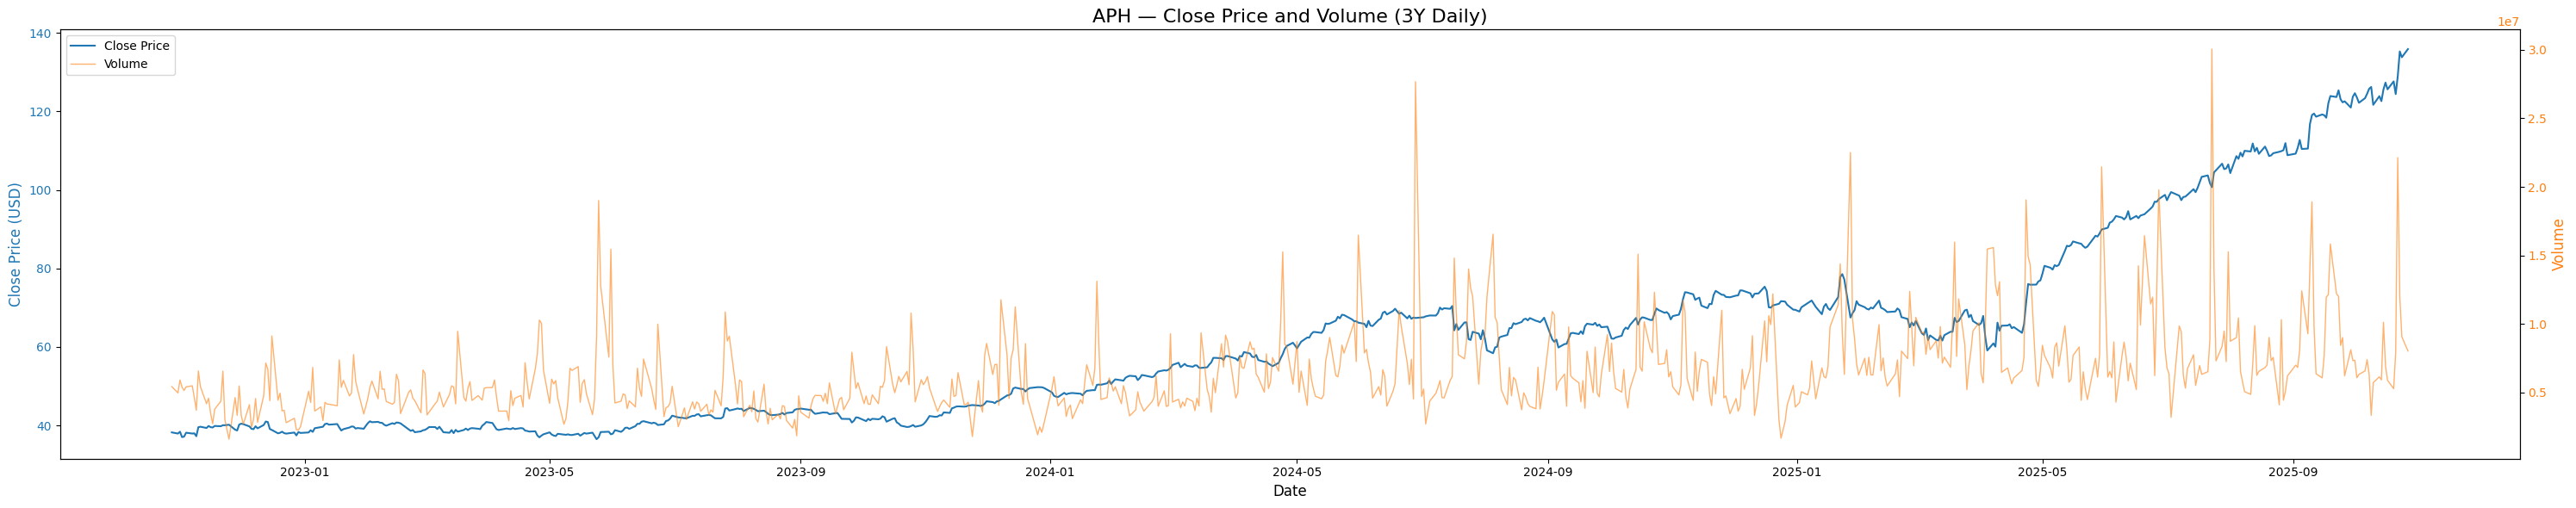

In [8]:
StockPlot('APH')

In [9]:
import os
file_path = os.path.join('data_test', 'df_industry_sector')
os.path.exists(file_path)

False

In [48]:
stock_tbl = StockFilter_SwingScreen( stock_list = stock_list)
# stock_tbl_to_save = stock_tbl[stock_tbl.industry_name != 'X']
# stock_tbl_to_save['closed_date'] = closed_date

S&P 500 recently is going up? False
CHLSY
HSY
AONNF
AONNF: Not enought data point
AONNY
MAKSF
MAKSY
RYKKF
RYKKF: Not enought data point
RYKKY
SVTMF
SVTMF: Not enought data point
ADDDF
ADDYY
ASCCF
ASCCY
DECK
ONON
CNC
HUM
MOH
AMCCF
AMCR
AVY
BALL
CCK
IP
PKG
SW
DHI
LEN
LEN-B
NVR
PHM
SKHSF
SKHSY
TOL
FSLR
NXT
BBY
CASY
DKS
GME
SNROF
SNROY
SNROY: Not enought data point
TSCO
ULTA
WSM


In [49]:
stock_tbl

,industry_name,industry_code,stock_code,macd_bullish,price_above_8dma,dma_3_gt_21,volume_surge,count_pass
7,Footwear & Accessories,^YH10240030,ADDYY,True,True,True,True,4
6,Footwear & Accessories,^YH10240030,ADDDF,True,True,True,False,3
13,Healthcare Plans,^YH20630010,HUM,True,True,True,False,3
0,Confectioners,^YH20525010,CHLSY,False,True,True,False,2
15,Packaging & Containers,^YH10250010,AMCCF,False,True,False,True,2
37,Specialty Retail,^YH10280060,SNROF,False,True,True,False,2
35,Specialty Retail,^YH10280060,DKS,False,True,True,False,2
33,Specialty Retail,^YH10280060,BBY,False,True,True,False,2
32,Solar,^YH31130030,NXT,False,True,True,False,2
30,Residential Construction,^YH10230010,TOL,False,True,True,False,2


In [50]:
from urllib.request import urlopen

In [51]:
import certifi
import json



def get_jsonparsed_news_data(url):
    response = urlopen(url, cafile=certifi.where())
    data = response.read().decode("utf-8")
    return json.loads(data)

url = (f'''https://financialmodelingprep.com/stable/price-target-news?symbol=AAPL&page=0&limit=10&apikey={API_key}''')
print(get_jsonparsed_data(url))

NameError: name 'API_key' is not defined

In [ ]:
yf.Ticker('^YH31130020').info